--- Splitting Data ---
Training Data: 5515 minutes (Used to find Hedge Ratio)
Testing Data: 3677 minutes (Used to trade)
Calculated Hedge Ratio: 0.0423 (Short 0.0423 BTC for every 1 ETH)
ADF P-Value (Stationarity Check): 0.47747


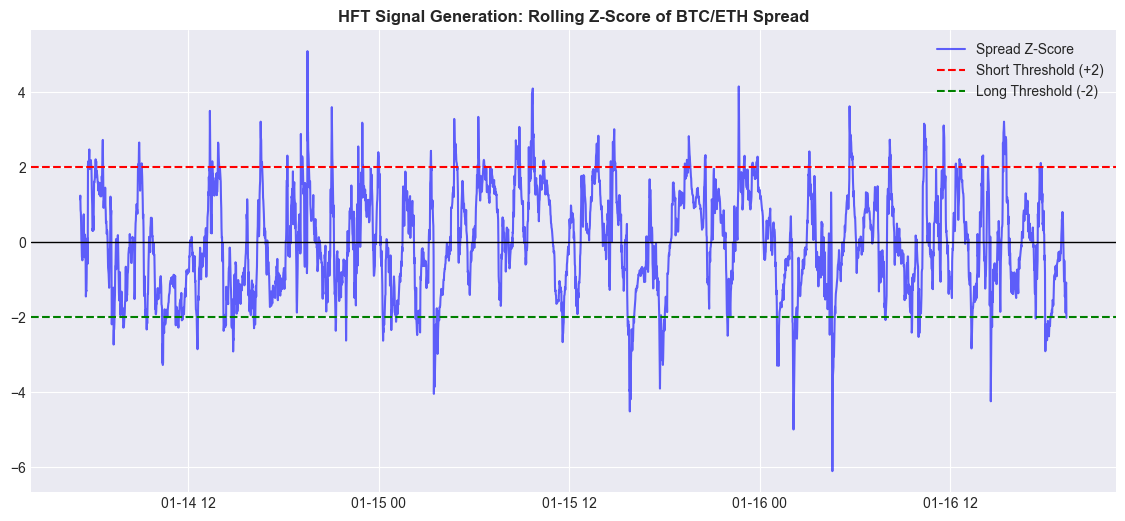

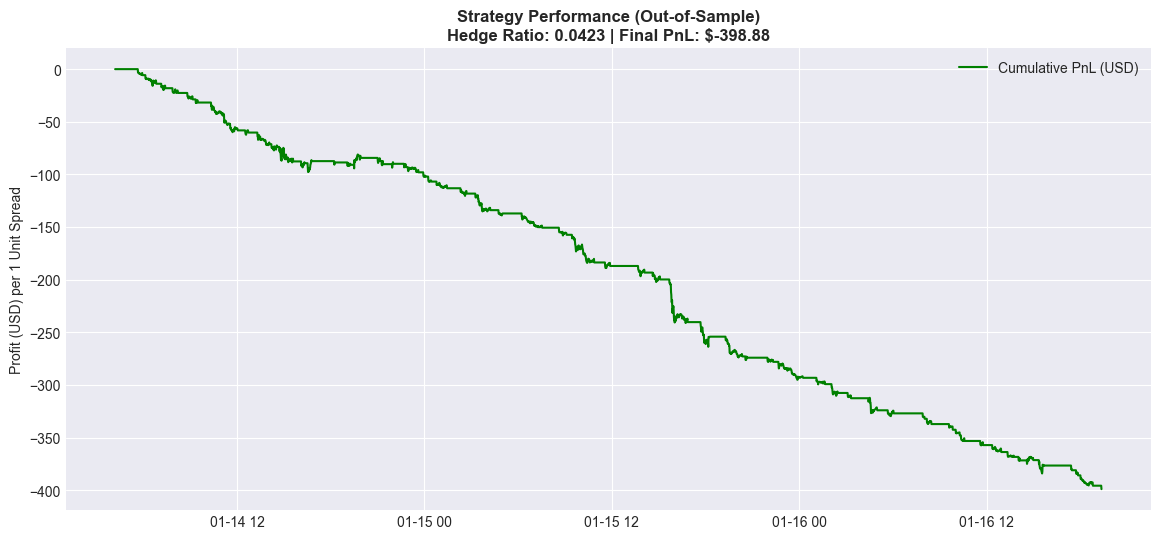


Backtest complete. Results saved to 'hft_results.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8-darkgrid')

def calculate_hedge_ratio(y, x):
    """
    Calculates the hedge ratio (beta) using OLS regression.
    y = beta * x + alpha
    """
    x = sm.add_constant(x)
    model = sm.OLS(y, x).fit()
    return model.params.iloc[1] # Return beta

def calculate_zscore(series, window=60):
    """
    Calculates rolling Z-Score to adapt to changing volatility.
    """
    r_mean = series.rolling(window=window).mean()
    r_std = series.rolling(window=window).std()
    return (series - r_mean) / r_std

def run_backtest(df, entry_z=2.0, exit_z=0.0, transaction_cost=0.001):
    """
    Backtests the Pairs Trading strategy on OUT-OF-SAMPLE data.
    """
    # 1. Split Data (60% Train, 40% Test)
    split = int(len(df) * 0.6)
    train = df.iloc[:split]
    test = df.iloc[split:].copy()
    
    print(f"--- Splitting Data ---")
    print(f"Training Data: {len(train)} minutes (Used to find Hedge Ratio)")
    print(f"Testing Data: {len(test)} minutes (Used to trade)")
    
    # 2. Cointegration Test on TRAINING Data
    # We treat ETH as Y (dependent) and BTC as X (independent)
    hedge_ratio = calculate_hedge_ratio(train['ETH-USD'], train['BTC-USD'])
    print(f"Calculated Hedge Ratio: {hedge_ratio:.4f} (Short {hedge_ratio:.4f} BTC for every 1 ETH)")
    
    # Check Stationarity of the Spread in Training
    train_spread = train['ETH-USD'] - (hedge_ratio * train['BTC-USD'])
    adf_result = adfuller(train_spread)
    print(f"ADF P-Value (Stationarity Check): {adf_result[1]:.5f}")
    if adf_result[1] > 0.05:
        print("WARNING: Spread may not be stationary! Strategy risks divergence.")
    else:
        print("SUCCESS: Spread is Stationary (Mean-Reverting). Proceeding...")

    # 3. Strategy Execution on TESTING Data
    # Calculate Spread on Test data using TRAINED Hedge Ratio
    test['Spread'] = test['ETH-USD'] - (hedge_ratio * test['BTC-USD'])
    
    # Calculate Rolling Z-Score (60-minute window)
    test['Z_Score'] = calculate_zscore(test['Spread'], window=60)
    
    # Signal Logic
    test['Position'] = 0 # 1 = Long Spread, -1 = Short Spread
    
    # Long Spread (Buy ETH, Sell BTC) when Z < -Entry
    # Short Spread (Sell ETH, Buy BTC) when Z > +Entry
    # Exit when Z crosses zero
    
    position = 0
    positions = []
    
    for z in test['Z_Score']:
        if z > entry_z:
            position = -1 # Short Spread
        elif z < -entry_z:
            position = 1 # Long Spread
        elif abs(z) < 0.5: # Exit near mean (0.5 buffer)
            position = 0
        positions.append(position)
        
    test['Position'] = positions
    
    # 4. PnL Calculation
    # Strategy Return = Position * (Change in Spread)
    # Note: This is a simplified PnL. Real PnL involves calculating returns of individual legs.
    # Approximation: Spread Change / Price of ETH approx return
    test['Spread_Change'] = test['Spread'].diff()
    test['Strategy_PnL_Gross'] = test['Position'].shift(1) * test['Spread_Change']
    
    # Transaction Costs (Paid on entry and exit changes)
    test['Trades'] = test['Position'].diff().abs()
    # Cost estimate: Price * fee. Here we approximate in $ terms relative to spread
    # Simplified: Assuming $1000 capital, cost is roughly $1 per trade leg
    # We will compute PnL in DOLLARS assuming 1 Unit of Spread Traded
    test['Cost'] = test['Trades'] * (test['ETH-USD'] * transaction_cost) 
    
    test['Strategy_PnL_Net'] = test['Strategy_PnL_Gross'] - test['Cost']
    test['Cumulative_PnL'] = test['Strategy_PnL_Net'].cumsum()
    
    return test, hedge_ratio

if __name__ == "__main__":
    # Load Data
    data = pd.read_csv('hft_pair_data.csv', index_col=0, parse_dates=True)
    
    # Run Strategy
    results, beta = run_backtest(data)
    
    # --- PLOTTING ---
    # Plot 1: Z-Score and Signals
    plt.figure(figsize=(14, 6))
    plt.plot(results.index, results['Z_Score'], label='Spread Z-Score', color='blue', alpha=0.6)
    plt.axhline(2.0, color='red', linestyle='--', label='Short Threshold (+2)')
    plt.axhline(-2.0, color='green', linestyle='--', label='Long Threshold (-2)')
    plt.axhline(0, color='black', linewidth=1)
    plt.title('HFT Signal Generation: Rolling Z-Score of BTC/ETH Spread', fontsize=12, fontweight='bold')
    plt.legend(loc='upper right')
    plt.show()
    
    # Plot 2: Cumulative PnL
    plt.figure(figsize=(14, 6))
    plt.plot(results.index, results['Cumulative_PnL'], label='Cumulative PnL (USD)', color='green')
    plt.title(f'Strategy Performance (Out-of-Sample)\nHedge Ratio: {beta:.4f} | Final PnL: ${results["Cumulative_PnL"].iloc[-1]:.2f}', fontsize=12, fontweight='bold')
    plt.ylabel('Profit (USD) per 1 Unit Spread')
    plt.legend()
    plt.show()
    
    # Save results
    results.to_csv('hft_results.csv')
    print("\nBacktest complete. Results saved to 'hft_results.csv'")